In [1]:
import json
import numpy as np
# import sys
# sys.path.append('/work/celani/ewp-rkpipi')
import matplotlib.pyplot as plt
from utils.plot_helpers import matplotlib_lhcb_style
matplotlib_lhcb_style(plt)
import matplotlib.font_manager as fm

# Specify the font file path
font_path = '/home/lhcb/celani/miniconda3/envs/rkpipi/fonts/FreeSerifItalic.otf'
# Register the font
fm.fontManager.addfont(font_path)
plt.rcParams['text.usetex'] = False

Welcome to JupyROOT 6.20/06


In [2]:
names_dic = {
    'TaggingEfficiency': r'$\varepsilon_{\mathrm{tag}}$',
    'TaggingEfficiency_Cali': r'$\varepsilon^{\mathrm{cali}}_{\mathrm{tag}}$',
    'EffectiveMistag': r'$\omega$',
    'EffectiveMistag_Cali': r'$\omega^{\mathrm{cali}}$',
    'TaggingPower': r'$\varepsilon_{tag,\mathrm{eff}}$',
    'TaggingPower_Cali': r'$\varepsilon_{tag,\mathrm{eff}}^{\mathrm{cali}}$'
}

In [7]:
# nom = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig/taggingInfo.json'
no_ghosts = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_noGhosts/taggingInfo.json'
eta_47 = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_eta4.7/taggingInfo.json'
eta_48 = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_eta4.8/taggingInfo.json'
# low_pt = '/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig_lowPT/taggingInfo.json'

# with open(nom) as f:
#     _nom = json.load(f)
with open(eta_47) as f:
    _eta47 = json.load(f)
with open(eta_48) as f:
    _eta48 = json.load(f)
with open(no_ghosts) as f:
    _nogh = json.load(f)
# with open(low_pt) as f:
#     _lowpt = json.load(f)

In [ ]:
for n in names_dic:
    if 'Cali' in n:
        print(n)
        # print('Nom', np.round(_nom[n][0]*100,2), '+-', np.round(_nom[n][1]*100,2))
        # print('No ghosts', np.round(_nogh[n][0],4), '+-', np.round(_nogh[n][1],4))
        # print('eta>4.7', np.round(_eta47[n][0],4), '+-', np.round(_eta47[n][1],4))
        # print('eta>4.8', np.round(_eta47[n][0],4), '+-', np.round(_eta48[n][1],4), '\n')
        # print('low PT K', np.round(_lowpt[n][0]*100,2), '+-', np.round(_lowpt[n][1]*100,2), '\n')


In [ ]:
xvals = [n for n in names_dic.keys()]
x_names = [names_dic[n] for n in xvals]
# yvals_nom = [_nom[k][0] for k in xvals]
# yerr_nom = [_nom[k][1] for k in xvals]
yvals_eta47 = [_eta47[k][0] for k in xvals]
yerr_eta47 = [_eta47[k][1] for k in xvals]
yvals_eta48 = [_eta48[k][0] for k in xvals]
yerr_eta48 = [_eta48[k][1] for k in xvals]
yvals_nogh = [_nogh[k][0] for k in xvals]
yerr_err_nogh = [_nogh[k][1] for k in xvals]
plt.ylim(-0.1,1.0)
plt.xlim(0.,6.)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nom, yerr=yerr_nom, label='Nominal', fmt='^', color="navy", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nogh, yerr=yerr_err_nogh, label='No ghosts', fmt='^', color="darkgreen", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_trueid, yerr=yerr_trueid, label=r'$|\mathrm{TRUEID}(tag)!=0$', fmt='v', color="orange", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta47, yerr=yerr_eta47, label=r'$\eta(B, \mathrm{tag})<4.7$', fmt='v', color="orange", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta48, yerr=yerr_eta48, label=r'$\eta(B, \mathrm{tag})<4.8$', fmt='v', color="darkred", markersize=8)
plt.xticks(np.arange(len(xvals)) + 0.5, x_names)
plt.title('OSKaon using $J/\psi K^+$ 2024 MC with UT')
plt.legend(loc='best')
plt.show()
plt.close()

In [3]:
def read_params(k, i, par):
    file = f"/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig_lowPT/{k}/{i}/taggingInfo.json"
    with open(file) as f:
        _par = json.load(f)
    return _par[par][0]*100, _par[par][1]*100

In [4]:
par = 'TaggingPower_Cali'
# par = 'EffectiveMistag_Cali'
# par = 'TaggingEfficiency_Cali'
nom_val = []
asPi_val = []
asK_val = []
nom_err = []
asPi_err = []
asK_err = []
for i in range(5):
    nom_v, nom_e = read_params('nom_2', i+1, par)
    nom_val.append(nom_v)
    nom_err.append(nom_e)
    asPi_v, asPi_e = read_params('smear_baseline', i+1, par)
    asPi_val.append(asPi_v)
    asPi_err.append(asPi_e)
    asK_v, asK_e = read_params('smear_heavy', i+1, par)
    asK_val.append(asK_v)
    asK_err.append(asK_e)

In [15]:
def read_params_shreya(k, i, par):
    # file = f"/auto/data/celani/FT/savedModels/withUT_MC_2024/Bu2JpsiK/OSKaon/cut_Run2Summer2017Opt_v2_noProbNN_IPSig_lowPT/{k}/{i}/taggingInfo.json"
    if k == 'nom':
        file = f"/auto/data/sroy/FT/savedModels/withUT_MC_2024/Bs2DsPi/SSKaon/run2_lowpt_sr1_recopv/{i}/taggingInfo.json"
    elif k == '500_ghostsAsKaons':
        file = f"/auto/data/sroy/FT/savedModels/withUT_MC_2024/Bs2DsPi/SSKaon/trun2_lowpt_sr1_recopv/{i}/taggingInfo.json"
    elif k == '500_ghostsAsPions':
        file = f"/auto/data/sroy/FT/savedModels/withUT_MC_2024/Bs2DsPi/SSKaon/trun2_lowpt_sr1_recopv_pionghost/{i}/taggingInfo.json"
    with open(file) as f:
        _par = json.load(f)
    return _par[par][0]*100, _par[par][1]*100

In [21]:
# par = 'TaggingPower_Cali'
# par = 'EffectiveMistag_Cali'
par = 'TaggingEfficiency_Cali'
nom_val = []
asPi_val = []
asK_val = []
nom_err = []
asPi_err = []
asK_err = []
for i in [1,2,3,5,6,8,11,12,13,14]:
    nom_v, nom_e = read_params_shreya('nom', i, par)
    nom_val.append(nom_v)
    nom_err.append(nom_e)
    asPi_v, asPi_e = read_params_shreya('500_ghostsAsPions', i, par)
    asPi_val.append(asPi_v)
    asPi_err.append(asPi_e)
    asK_v, asK_e = read_params_shreya('500_ghostsAsKaons', i, par)
    asK_val.append(asK_v)
    asK_err.append(asK_e)


NameError: name 'read_params_shreya' is not defined

NameError: name 'names_dic' is not defined

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

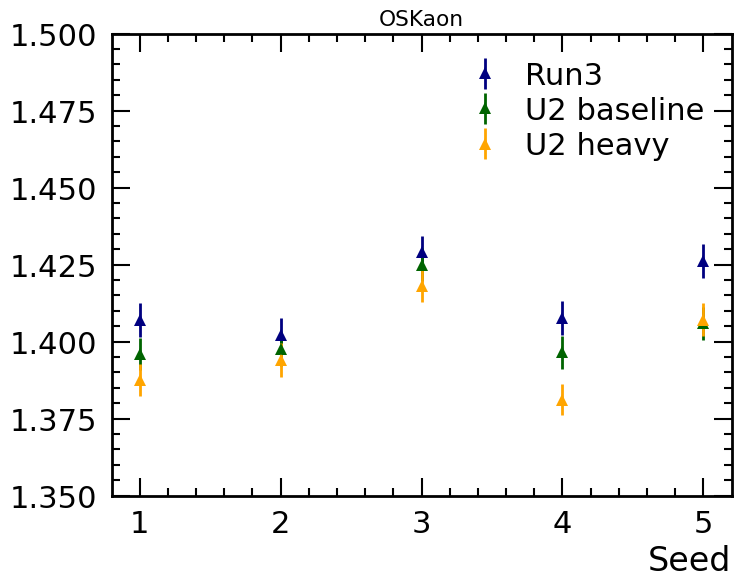

In [6]:
plt.ylim(1.35, 1.50)
# plt.ylim(55, 80)
# plt.xlim(0.,6.)
xvals = [(i+1) for i in range(5)]
# xvals = [1,2,3,5,6,8,11,12,13,14]
plt.errorbar(np.arange(len(xvals)) + 0.5, nom_val, yerr=nom_err, label='Run3', fmt='^', color="navy", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, asPi_val, yerr=asPi_err, label=r'U2 baseline', fmt='^', color="darkgreen", markersize=8)
plt.errorbar(np.arange(len(xvals)) + 0.5, asK_val, yerr=asK_err, label=r'U2 heavy', fmt='^', color="orange", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_nogh, yerr=yerr_err_nogh, label='No ghosts', fmt='^', color="darkgreen", markersize=8)
# # plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_trueid, yerr=yerr_trueid, label=r'$|\mathrm{TRUEID}(tag)!=0$', fmt='v', color="orange", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta47, yerr=yerr_eta47, label=r'$\eta(B, \mathrm{tag})<4.7$', fmt='v', color="orange", markersize=8)
# plt.errorbar(np.arange(len(xvals)) + 0.5, yvals_eta48, yerr=yerr_eta48, label=r'$\eta(B, \mathrm{tag})<4.8$', fmt='v', color="darkred", markersize=8)
plt.xticks(np.arange(len(xvals)) + 0.5, xvals)
# plt.title('OSKaon using $J/\psi K^+$ 2024 MC with UT')
plt.title('OSKaon')
plt.legend(loc='best')
plt.xlabel('Seed')
plt.ylabel(names_dic[par] + (r'$~(\%)$'))
plt.show()
plt.close()

In [11]:
print(np.mean(nom_val))
print(np.mean(asPi_val))
print(np.mean(asK_val))

1.4143467622550112
1.40420978933574
1.3975776281791927


In [12]:
print(np.std(nom_val))


0.010939818289313103


In [ ]:
type = 'NO TORCH'
# type = 'Ghosts as kaons'
# type = 'Ghosts as pions'
# print(type + '\n')
print(par + ' (%)\n')
for i in range(5):
    # print(f'Seed {i+1}', np.round(nom_val[i],2), '+-', np.round(nom_err[i],2))
    # print(f'Seed {i+1}', np.round(asK_val[i],2), '+-', np.round(asK_err[i],2))
    print(f'Seed {i+1}', np.round(asPi_val[i],2), '+-', np.round(asPi_err[i],2))
